## Exploratory Data Analysis (EDA) of Antibiotic Resistance Patterns in Stanford Healthcare Dataset

Author: Sam Zavislan-Pullaro

Github: https://github.com/sdzavislan/Exploratory-Data-Analysis-of-Antibiotic-Resistance-Patterns-in-Stanford-Healthcare-Dataset.git

### Dataset:
The Antibiotic Resistance Microbiology Dataset (ARMD)
(doi.org/10.5061/dryad.jq2bvq8kp) [1].

### Objective:
The aim of this exploratory data analysis is to identify patterns of antimicrobial resistance across selected organisms, culture types, and antibiotic susceptibility profiles. A particular challenge of this dataset is the ambiguity of patient demographics. This dataset contains clinical information from real patient data, and was collected using electronic health records from Stanford Healthcare. Demographic features have undergone thorough de-identification. Ages have been aggregated into bins of age ranges (e.g. 18- 24, 25-34, 35-44, etc.). Genders are labeled as binary classifiers (1 and 0), without indicating which value corresponds to male or female. For the context of this EDA, demographics will not be used to form causal associations.

### Specific questions to address:
1) Which organisms show the highest resistance rates?
2) What are the resistance profiles of specific antibiotics across selected organisms with high clinical relevance?
3) What proportion of selected organisms are present across sample types (urine, blood, respiratory)?

### Dataset Reference: Version Oct 22, 2025
[1] Nateghi Haredasht, Fateme; Amrollahi, Fatemeh; Maddali, Manoj et al. (2025). Antibiotic
Resistance Microbiology Dataset (ARMD): A resource for antimicrobial resistance from EHRs
[Dataset]. Dryad. https://doi.org/10.5061/dryad.jq2bvq8kp


In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Sub-datasets:
`demographics.csv`: Includes patient demographic information at the time of the culture order.

`adi_scores.csv`: Contains Area Deprivation Index (ADI) data mapped to cohort ZIP codes (the ZIP codes were removed from this dataset for patient de-identification).

`cohort.csv`: Contains primary information about microbiological cultures, including culture type, organism identified, and antibiotic susceptibility.

`resistance.csv`: Contains data on microbial resistance and the timeline of resistance development.

In [84]:
dem_df = pd.read_csv('demographics.csv', dtype={"gender": str})
adi_df = pd.read_csv('adi_scores.csv', low_memory=False)
cohort_df = pd.read_csv('cohort.csv')
res_df = pd.read_csv('resistance.csv')

### General demographics
* Demographics will not be used to compare infection and resistence patterns. However, it is still relevant information to include in an exploratory data analysis.

In [85]:
dem_df.head(10)

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,age,gender
0,JC1212710,131008781669,364609652,25-34 years,Null
1,JC1218441,33052060,351667304,25-34 years,Null
2,JC1261412,131004002288,355531114,25-34 years,Null
3,JC1224853,19532426,335118697,25-34 years,Null
4,JC1242725,32587123,349578403,25-34 years,Null
5,JC1253207,131010152115,369993038,25-34 years,Null
6,JC6332973,131343072572,830478384,18-24 years,1
7,JC5134781,131338982456,819348359,18-24 years,1
8,JC2497630,131247298126,557242173,18-24 years,1
9,JC2490513,131029317732,433305220,18-24 years,1


#### Note: Genders have been de-identified to 0 and 1 to protect patient confidentiality.
* Gender information will not be used in this exploratory data analysis.
* However, it is worth noting the imbalance of gender counts:

  * 0 = 478814
  * 1 = 272141
  * Null = 120

In [86]:
dem_df['gender'].value_counts()

gender
0       478814
1       272141
Null       120
Name: count, dtype: int64

In [87]:
# Strip letters and count age bin values
counts = dem_df['age'].str.replace(r'[a-z]', '', regex=True).str.strip().value_counts()
counts

age
65-74    130764
55-64    122486
75-84    100915
25-34     99023
35-44     93245
45-54     93033
18-24     47509
85-89     34458
90        29642
Name: count, dtype: int64

In [88]:
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-84', '85-89', '90']
counts = counts[age_order]

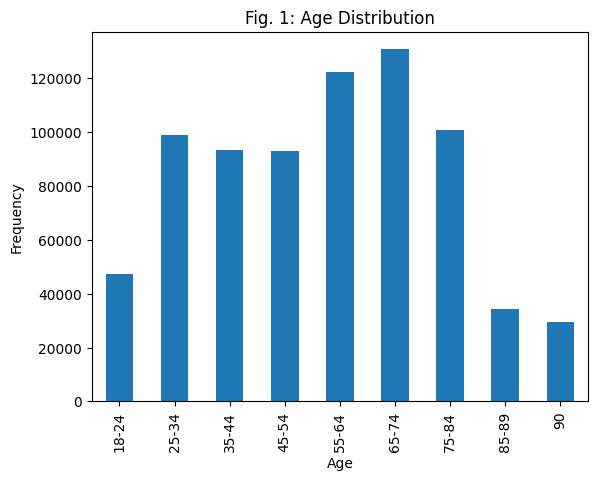

In [133]:
counts.plot(kind = "bar")
plt.title("Fig. 1: Age Distribution")
plt.ylabel("Frequency")
plt.xlabel("Age")
plt.show()

### ADI Scores

Area Deprivation Index (ADI): This is a scoring metric used to rank neighborhood-level socioeconomic disadvantage.
* Scores range from 1 (lowest deprivation) - 100 (highest deprivation).
* The majority of patients in this dataset (79.3%) score between 1-10 ADI, excluding missing data as 'Null' type.
    * 1-10 = 79.3%
    * 1-50 = 97.6%
    * 51-100 = 2.4%
* The socioeconomic status of patients covered by Stanford Healthcare are predominantly in the lowest deprivation.
* Indicative of low disadvantage for housing, income, education, and housing.

**Conclusion:** The majority of patients come from high socioeconomic status.

In [90]:
adi_df.head(5)

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,adi_score,adi_state_rank
0,JC6213422,131321523364,759748723,2021-11-19 08:30:00+00:00,Null,Null
1,JC6298763,131361363555,902110506,2023-09-30 20:18:00+00:00,Null,Null
2,JC6272591,131340198255,818636183,2022-10-05 03:27:00+00:00,Null,Null
3,JC1317627,131017484560,396745616,2012-01-26 02:04:00+00:00,Null,Null
4,JC1523941,131020403526,406388185,2012-09-10 03:22:00+00:00,Null,Null


In [91]:
(adi_df['adi_score'] == 'Null').value_counts()

adi_score
False    588272
True     162803
Name: count, dtype: int64

In [92]:
# Drop nulls, count total adi scores retained
adi_retained = adi_df['adi_score'].replace('Null', pd.NA).dropna().astype(int)
adi_retained.count(), adi_retained.shape

(np.int64(588272), (588272,))

In [93]:
# ADI score counts
adi_counts = adi_retained.value_counts().sort_index()
adi_counts

adi_score
1      177757
2       81244
3       60589
4       40903
5       33882
        ...  
96         20
97         38
98         36
99         42
100        25
Name: count, Length: 100, dtype: int64

In [94]:
# Percentage of patients with ADI score 1-10
(adi_counts[0:10].sum() / adi_retained.count()) * 100

np.float64(79.30634128430385)

In [95]:
# Percentage of patients with ADI score 1-50
(adi_counts[0:50].sum() / adi_retained.count()) * 100

np.float64(97.61929855577011)

In [96]:
# Percentage of patients with ADI score above 50
(adi_counts[50:100].sum() / adi_retained.count()) * 100

np.float64(2.38070144422988)

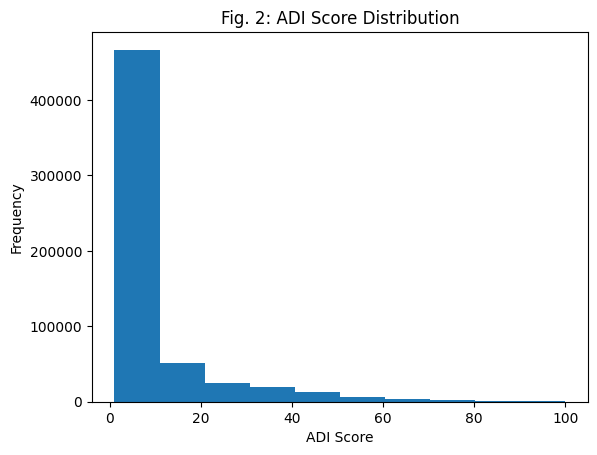

In [135]:
adi_retained.plot(kind='hist', bins = 10, xlabel='ADI Score', ylabel='Frequency', title='Fig. 2: ADI Score Distribution')
plt.show()

### 1) Which organisms show the highest resistance rates?

Description ``cohort_df``: Contains primary information about microbiological cultures, including culture type, organism identified, and antibiotic susceptibility.

Key columns:
* `culture_description`: Culture type (Blood, Urine, or Respiratory)
* `was_positive`: Indicates whether the culture was positive for an organism (positive = 1).
* `organism`: Identified microorganism.
* `antibiotic`: Antimicrobial agent tested.
* `susceptibility`: Categorized susceptibility result (Susceptible, Resistant, or Intermediate).

In [98]:
cohort_df.head()

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,was_positive,organism,antibiotic,susceptibility
0,JC2744063,131368600230,928257722,2023-12-23 22:29:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
1,JC1713666,131300064625,697566032,2020-12-27 00:40:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
2,JC1669304,131272997044,620809641,2019-07-02 19:54:00+00:00,Inpatient,BLOOD,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
3,JC1697441,131208305006,510635146,2016-12-01 13:59:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
4,JC600786,131344486993,834128837,2022-11-18 19:35:00+00:00,Outpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible


In [99]:
mode_counts = cohort_df['ordering_mode'].value_counts()
mode_counts

ordering_mode
Inpatient     1238720
Outpatient     929288
Null            73042
Name: count, dtype: int64

#### Percentage of order mode types
* The majority of ordering modes come from inpatient facilities (55.3%)

In [100]:
mode_sum = mode_counts.sum()
mode_prop = mode_counts.div(mode_sum, axis=0) * 100
mode_prop

ordering_mode
Inpatient     55.274090
Outpatient    41.466634
Null           3.259276
Name: count, dtype: float64

#### Note:

Null counts indicate missing data for ordering mode

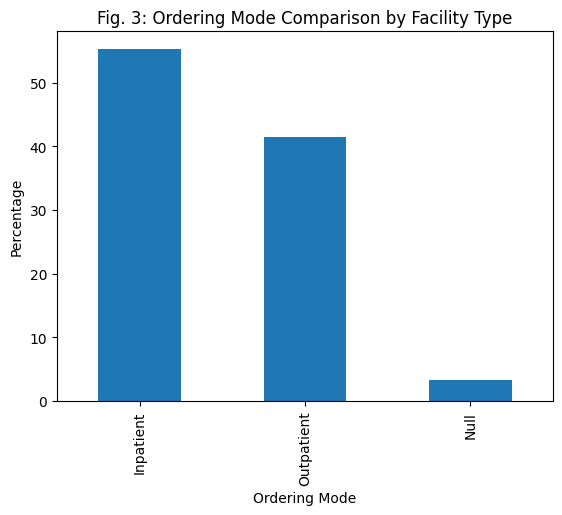

In [137]:
mode_prop.plot(kind = 'bar', xlabel = 'Ordering Mode', ylabel = 'Percentage', title = 'Fig. 3: Ordering Mode Comparison by Facility Type')
plt.show()

### Notable organisms with high detection frequency

1) *E. coli* : Common cause of urinary tract infections (UTIs)
2) *K. pneumoniae* : Common cause of UTIs, blood infections, and pneumonia
3) *P. aeruginosa* : Common cause of UTIs, skin infections, lung infections (particularly in patients with cystic fibrosis), and sepsis. Has high clinical relevance.
4) *S. aureus* (MRSA) : Methicilin Resistant *Staphylococcus Aureus* (MRSA) has high mortality rate association. Common cause of many infection types. Can cause life-threatening illness in immunocompromised individuals.

Subsequence analysis will focus of these organisms to determine source of infection and antibiotic resistance/succeptability.

In [102]:
# Count 'Null'
(cohort_df['organism'] == 'Null').value_counts()

organism
False    1608742
True      632308
Name: count, dtype: int64

Below indicates positive infections with organisms labeled as 'Null' (not identified to species level)

In [103]:
((cohort_df['organism'] == 'Null') & (cohort_df['was_positive'] == 1)).value_counts()

False    2239540
True        1510
Name: count, dtype: int64

In [104]:
# Count number of times each organism was detected. Display top 11 results to include MRSA
cohort_df[cohort_df['organism'] != 'Null']['organism'].value_counts().head(11)

organism
ESCHERICHIA COLI                 874897
KLEBSIELLA PNEUMONIAE            151964
STAPHYLOCOCCUS AUREUS             82519
PROTEUS MIRABILIS                 67938
ENTEROCOCCUS SPECIES              64511
PSEUDOMONAS AERUGINOSA            48959
MUCOID PSEUDOMONAS AERUGINOSA     33037
KLEBSIELLA OXYTOCA                25066
ENTEROBACTER CLOACAE COMPLEX      24042
COAG NEGATIVE STAPHYLOCOCCUS      20866
STAPH AUREUS {MRSA}               16674
Name: count, dtype: int64

In [105]:
# Mask for selected organisms with high clinical relevance
selected_organisms_cohort = ((cohort_df['organism'] == 'ESCHERICHIA COLI') |
          (cohort_df['organism'] == 'STAPH AUREUS {MRSA}') |
          (cohort_df['organism'] == 'PSEUDOMONAS AERUGINOSA') |
          (cohort_df['organism'] == 'KLEBSIELLA PNEUMONIAE'))

cohort_df_filtered = cohort_df[selected_organisms_cohort]

In [106]:
cohort_df_filtered['organism'].value_counts()

organism
ESCHERICHIA COLI          874897
KLEBSIELLA PNEUMONIAE     151964
PSEUDOMONAS AERUGINOSA     48959
STAPH AUREUS {MRSA}        16674
Name: count, dtype: int64

Below, we can see that detection of *E.coli* dominates the proportion of total samples tested. It will be interesting to see the proportionality of cultures detected with confirmed resistance (ie not susceptible).

In [107]:
(cohort_df_filtered['organism'].value_counts() / cohort_df['organism']
 .value_counts().sum()) * 100

organism
ESCHERICHIA COLI          39.039602
KLEBSIELLA PNEUMONIAE      6.780929
PSEUDOMONAS AERUGINOSA     2.184646
STAPH AUREUS {MRSA}        0.744026
Name: count, dtype: float64

In [108]:
resistant_filtered = cohort_df_filtered[(cohort_df_filtered['susceptibility'] != 'Susceptible')]
positive_cultures = cohort_df[cohort_df['was_positive'] == 1]

Of all positive cultures, what proportion were made up by the selected organisms with confirmed resistance.

In [109]:
(resistant_filtered['organism'].value_counts() / positive_cultures['organism'].value_counts().sum()) * 100

organism
ESCHERICHIA COLI          9.026165
KLEBSIELLA PNEUMONIAE     1.707931
PSEUDOMONAS AERUGINOSA    0.555131
STAPH AUREUS {MRSA}       0.463592
Name: count, dtype: float64

Now, lets look at the proportion of organisms with resistance to the total number of times each selected organism was detected.

MRSA comes out of top, with the highest proportion of resistance to at least one antibiotic drug physically tested in a lab (44.8%).

In [110]:
((resistant_filtered['organism'].value_counts() / cohort_df_filtered['organism'].value_counts()) * 100).sort_values(ascending = False)

organism
STAPH AUREUS {MRSA}       44.770301
PSEUDOMONAS AERUGINOSA    18.258134
KLEBSIELLA PNEUMONIAE     18.097707
ESCHERICHIA COLI          16.612698
Name: count, dtype: float64

### 2) What are the resistance profiles of specific antibiotics across selected organisms with high clinical relevance?

Description of ``res_df`` : Contains data on microbial resistance and the timeline of resistance development.

In [111]:
res_df.head(5)

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,organism,antibiotic,resistant_time_to_culturetime
0,JC1255618,131301644146,701878721,2020-12-18 01:18:00+00:00,MYCOBACTERIUM ABSCESSUS,Minocycline,1266
1,JC533377,131311775703,737610687,2021-07-24 18:06:00+00:00,KLEBSIELLA PNEUMONIAE,Ertapenem,845
2,JC669033,131207605914,517925931,2017-01-30 23:31:00+00:00,BURKHOLDERIA CEPACIA,Minocycline,2231
3,JC1017583,131254647220,570493265,2018-08-03 02:00:00+00:00,MYCOBACTERIUM IMMUNOGENUM,Linezolid,812
4,JC2465442,131016167664,392129591,2011-12-18 16:21:00+00:00,PSEUDOMONAS AERUGINOSA,Colistin,210


### Organisms with *confirmed* resistance

Interestingly, the organisms with the highest frequencies of confirmed resistance were the organisms listed above with high clinical relevance (selected organisms). This is likely associated with the increased use of antibiotics to treat these infections, leading to higher resistance rates. However, this could also be confounded by the overall detection rates of these organisms given their clinical relevance.

In [112]:
res_df['organism'].value_counts().head(5)

organism
ESCHERICHIA COLI          563976
STAPHYLOCOCCUS AUREUS     386920
KLEBSIELLA PNEUMONIAE     146632
STAPH AUREUS {MRSA}       133732
PSEUDOMONAS AERUGINOSA    122509
Name: count, dtype: int64

In [113]:
res_df[['antibiotic']].value_counts()

antibiotic    
Ampicillin        296079
Levofloxacin      272318
Ciprofloxacin     271794
Penicillin        216220
Erythromycin      174856
Cefazolin         126078
Moxifloxacin      117759
Amikacin          116039
Gentamicin        104725
Ceftazidime        90002
Cefepime           79155
Nitrofurantoin     73241
Cefoxitin          58858
Ceftriaxone        55888
Meropenem          55546
Vancomycin         16209
Rifampin           13084
Linezolid           7539
Minocycline         4439
Ertapenem           4138
Clarithromycin      3955
Colistin            1879
Aztreonam           1696
Metronidazole        139
Cefpodoxime           10
Ethambutol             2
Name: count, dtype: int64

In [114]:
selected_organisms_res = ((res_df['organism'] == 'ESCHERICHIA COLI') |
    (res_df['organism'] == 'STAPH AUREUS {MRSA}') |
    (res_df['organism'] == 'PSEUDOMONAS AERUGINOSA') |
    (res_df['organism'] == 'KLEBSIELLA PNEUMONIAE'))

res_df_filtered = res_df[selected_organisms_res]
res_df_filtered.head(5)

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,organism,antibiotic,resistant_time_to_culturetime
1,JC533377,131311775703,737610687,2021-07-24 18:06:00+00:00,KLEBSIELLA PNEUMONIAE,Ertapenem,845
4,JC2465442,131016167664,392129591,2011-12-18 16:21:00+00:00,PSEUDOMONAS AERUGINOSA,Colistin,210
8,JC583837,131016475385,393293889,2012-01-05 18:31:00+00:00,PSEUDOMONAS AERUGINOSA,Colistin,410
9,JC1511757,131038640286,450177252,2014-09-24 17:18:00+00:00,ESCHERICHIA COLI,Ertapenem,32
10,JC577908,131129899796,484531768,2016-02-12 17:29:00+00:00,PSEUDOMONAS AERUGINOSA,Colistin,1360


In [115]:
res_pivot = res_df_filtered.pivot_table('anon_id', index='antibiotic', columns='organism', aggfunc='count')
res_pivot.head(5)

organism,ESCHERICHIA COLI,KLEBSIELLA PNEUMONIAE,PSEUDOMONAS AERUGINOSA,STAPH AUREUS {MRSA}
antibiotic,,,,
Amikacin,1159.0,464.0,31850.0,NaN
Ampicillin,155456.0,70131.0,26.0,NaN
Aztreonam,1495.0,50.0,13.0,NaN
Cefazolin,55026.0,10483.0,33.0,2574.0
Cefepime,13036.0,3086.0,13042.0,NaN


#### Normalize counts to find proportion of selected organisms resistant to each antibiotic tested

* This pivot table below shows the antibiotic resistance rate as a function of percent organism total (with resistance).
* This allows for easy identification of antibiotic drugs that are less effective for use in clinical settings for this patient population.

In [116]:
col_sums = res_pivot.sum(axis=0)
res_percent = (res_pivot / col_sums) * 100
res_percent

organism,ESCHERICHIA COLI,KLEBSIELLA PNEUMONIAE,PSEUDOMONAS AERUGINOSA,STAPH AUREUS {MRSA}
antibiotic,,,,
Amikacin,0.205505,0.316438,25.998090,NaN
Ampicillin,27.564294,47.827896,0.021223,NaN
Aztreonam,0.265082,0.034099,0.010611,NaN
Cefazolin,9.756798,7.149190,0.026937,1.924745
Cefepime,2.311446,2.104588,10.645748,NaN
Cefoxitin,2.677596,2.455126,NaN,NaN
Cefpodoxime,0.001773,NaN,NaN,NaN
Ceftazidime,3.939175,4.232364,10.235166,NaN
Ceftriaxone,6.197604,5.618146,0.003265,NaN


Fig. 4 shows a heatmap of different antibiotics tested for resistance against the selected organisms. It should be noted that each value represents a percentage of organisms tested with confirmed resistance to at least one antibiotic. Therefore, this figure is excluding organisms with susceptability to all antibiotics tested.

Summary:
* Ampicillin is less effective for treating *E.coli* and *K.pneumoniae*. Use of this antibiotic as a treatment for other pathogenic bacteria (especially gram-positive bacteria) can inadvertently select for survival of pathogenic gram-negatives, leading to a secondary infection in immunocompromised individuals.
* Broad resistence to levofloxacin, a broad-spectrum fluoroquinolone, used to treat both gram-negative and gram-positive bacteria.
* Gram-negative bacteria (*E.coli*, *K.pneumoniae*, and *P.aeruginosa*) typically carry beta-lactamase genes, which confer resistance to beta-lactam antibiotics.

Beta-lactams include:
1) Ampicillin
2) Penicillin
3) Cefazolin
4) Cefoxitin
5) Cefpodoxime
6) Ceftazidime
7) Ceftriaxone
8) Cefepime
9) Ertapenem
10) Meropenem

The broad resistance pattern for the gram-negatives against beta-lactams is what we would expect given they typically carry b-lactamase genes.

For *S.aureus*, we see high proportion of samples with confirmed resistance to:
1) Erythromycin
2) Levofloxacin
3) Moxifloxacin
4) Penicillin

These resistance mechanisms are likely a result of widespread use of antibiotics in clinical settings.

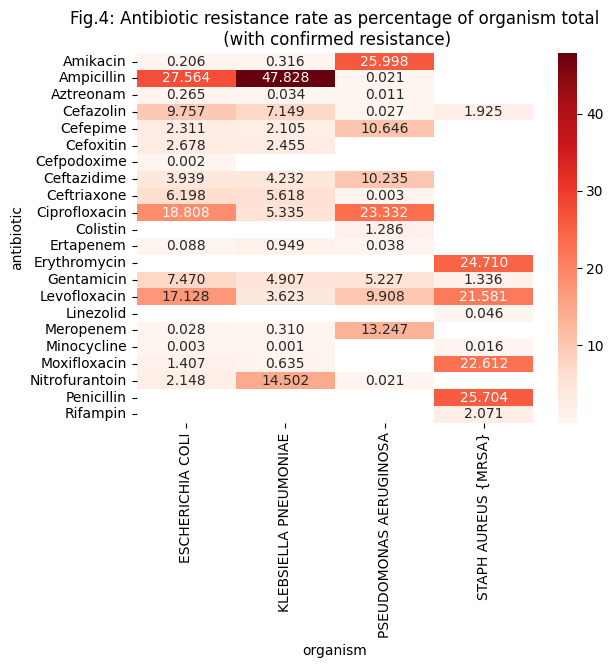

In [138]:
sns.heatmap(res_percent, annot=True, fmt='.3f', cmap="Reds")
plt.title("Fig.4: Antibiotic resistance rate as percentage of organism total\n (with confirmed resistance)")
plt.show()

### 3) What proportion of selected organisms are present across sample types (urine, blood, respiratory)?

Culture descriptions:

1) Blood
2) Respiratory
3) Urine

We will address this by using ``cohort_df_filtered``, and excluding samples that are susceptible to antibiotics.

In [118]:
cohort_df_filtered.head(5)

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,was_positive,organism,antibiotic,susceptibility
0,JC2744063,131368600230,928257722,2023-12-23 22:29:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
1,JC1713666,131300064625,697566032,2020-12-27 00:40:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
2,JC1669304,131272997044,620809641,2019-07-02 19:54:00+00:00,Inpatient,BLOOD,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
3,JC1697441,131208305006,510635146,2016-12-01 13:59:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
4,JC600786,131344486993,834128837,2022-11-18 19:35:00+00:00,Outpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible


In [119]:
# Filter for organisms not susceptible to antibiotics and positive culture result
resistant_df = cohort_df_filtered[(cohort_df_filtered['susceptibility'] != 'Susceptible') & (cohort_df_filtered['was_positive'] == 1)]
resistant_df.head(5)

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,was_positive,organism,antibiotic,susceptibility
41,JC650705,131018508530,400135436,2012-05-23 22:59:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ampicillin,Resistant
42,JC908609,14846556,323570622,2008-02-24 03:17:00+00:00,Outpatient,RESPIRATORY,1,KLEBSIELLA PNEUMONIAE,Ampicillin,Resistant
43,JC3185630,131323665880,765693532,2022-01-04 23:25:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ampicillin,Resistant
44,JC656063,131041080185,445830510,2014-08-22 04:57:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ampicillin,Resistant
45,JC1282801,131009373067,366941446,2010-04-20 18:34:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ampicillin,Resistant


In [130]:
ctype_pivot = resistant_df.pivot_table('anon_id', index='organism', columns='culture_description', aggfunc='count')
ctype_pivot

culture_description,BLOOD,RESPIRATORY,URINE
organism,,,
ESCHERICHIA COLI,11407,3182,130755
KLEBSIELLA PNEUMONIAE,2432,982,24088
PSEUDOMONAS AERUGINOSA,367,6706,1866
STAPH AUREUS {MRSA},2184,4832,449


Below is the same output using groupby to confirm results of previous pivot tables used in this EDA.

In [140]:
# Groupby confirmation of results
resistant_df.groupby('organism')['culture_description'].value_counts()

organism                culture_description
ESCHERICHIA COLI        URINE                  130755
                        BLOOD                   11407
                        RESPIRATORY              3182
KLEBSIELLA PNEUMONIAE   URINE                   24088
                        BLOOD                    2432
                        RESPIRATORY               982
PSEUDOMONAS AERUGINOSA  RESPIRATORY              6706
                        URINE                    1866
                        BLOOD                     367
STAPH AUREUS {MRSA}     RESPIRATORY              4832
                        BLOOD                    2184
                        URINE                     449
Name: count, dtype: int64

### Fig.5: Culture types of positive cases with confirmed resistance as a percentage of total counts per organism with resistance.
* *E.coli* and *K.pneumoniae* dominate for urine type cultures. This is an expected result as these organisms are common sources for urinary tract infections.
* *P.aeruginosa* and *S.aureus* (MRSA) dominate for respiratory type cultures. This is expected as patients who are immunocompromised in a clinical setting are at risk for respiratory infections caused by these organisms. This is typically induced by antibiotic use leading to opportunistic infections by organisms with broad resistance such as these. Individuals with cystic fibrosis are particularly affected by infections of the lungs in clinical settings.
* MRSA did report a higher frequency of positive cultures found in blood samples. This is particularly alarming, as MRSA induced sepsis has a high mortality rate.

In [70]:
ctype_pivot_sum = ctype_pivot.sum(axis=1)
ctype_percentage = ctype_pivot.div(ctype_pivot_sum, axis=0) * 100
ctype_percentage

culture_description,BLOOD,RESPIRATORY,URINE
organism,,,
ESCHERICHIA COLI,7.848277,2.189289,89.962434
KLEBSIELLA PNEUMONIAE,8.842993,3.570649,87.586357
PSEUDOMONAS AERUGINOSA,4.105605,75.019577,20.874818
STAPH AUREUS {MRSA},29.256530,64.728734,6.014735


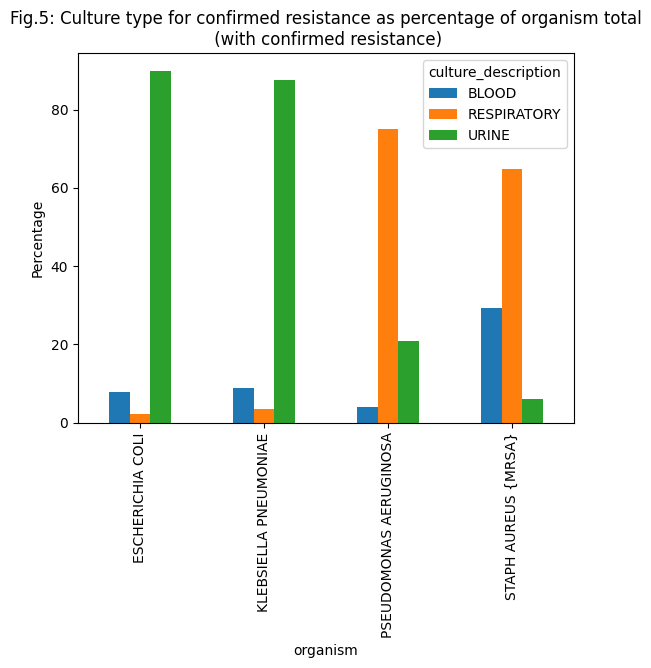

In [139]:
ctype_percentage.plot(kind='bar', ylabel='Percentage', title='Fig.5: Culture type for confirmed resistance as percentage of organism total\n (with confirmed resistance)')
plt.show()